In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_security.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

print("Dataset found:", DATA_PATH)

Dataset found: /Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/final_security.csv


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (9230, 13)

Columns:
['comment_id', 'comment', 'repo', 'language', 'pr_id', 'c_id', 'matched_strong', 'matched_weak', 'security_categories', 'candidate_score', 'indicator_strength', 'manual_label', 'review_notes']


,comment_id,comment,repo,language,pr_id,c_id,matched_strong,matched_weak,security_categories,candidate_score,indicator_strength,manual_label,review_notes
0,208849771,Should not `ansible.utils.encrypt.random_passw...,ansible,Python,21225735,1095841089,NaN,password; encryption,authentication; cryptography,2,weak,0,"Keyword appears while describing, implementing..."
1,258431281,These routes are quite a lot to copy in here. ...,AspNetCore,NaN,56148722,1303642745,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
2,269690752,slow-tests does also contain ssl-certificate r...,chainweb-node,Haskell,58703769,1341744273,NaN,ssl; certificate,cryptography,2,weak,0,"Keyword appears while describing, implementing..."
3,195074858,minikube start --bootstrapper localkube --extr...,service-manager,NaN,39143713,1005582331,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
4,224629987,There might be some confusion. I ran this cod...,hail,Scala,47236096,1161354134,NaN,secret; session,authentication; secrets,2,weak,1,Comment explicitly describes a security weakne...


In [4]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate full rows:", df.duplicated().sum())

if "comment_id" in df.columns:
    print("Duplicate comment IDs:", df["comment_id"].duplicated().sum())

Data types:


comment_id             int64
comment                  str
repo                     str
language                 str
pr_id                  int64
c_id                   int64
matched_strong           str
matched_weak             str
security_categories      str
candidate_score        int64
indicator_strength       str
manual_label           int64
review_notes             str
dtype: object


Missing values:


comment_id                0
comment                   0
repo                      0
language               2402
pr_id                     0
c_id                      0
matched_strong         6531
matched_weak           2047
security_categories       0
candidate_score           0
indicator_strength        0
manual_label              0
review_notes              0
dtype: int64


Duplicate full rows: 0
Duplicate comment IDs: 0


In [5]:
print(df.columns.tolist())
LABEL_COLUMN = "manual_label"
print("Using label column:", LABEL_COLUMN)
print(df[LABEL_COLUMN].value_counts(dropna=False))

['comment_id', 'comment', 'repo', 'language', 'pr_id', 'c_id', 'matched_strong', 'matched_weak', 'security_categories', 'candidate_score', 'indicator_strength', 'manual_label', 'review_notes']
Using label column: manual_label
manual_label
0    6119
1    3028
2      83
Name: count, dtype: int64


In [6]:
if "comment" not in df.columns:
    raise ValueError("The dataset does not contain a 'comment' column.")

TEXT_COLUMN = "comment"

df[TEXT_COLUMN] = df[TEXT_COLUMN].fillna("").astype(str)

print("Blank comments:", (df[TEXT_COLUMN].str.strip() == "").sum())

Blank comments: 0


Label distribution:


manual_label
0    6119
1    3028
2      83
Name: count, dtype: int64

Label percentages:


manual_label
0    66.29
1    32.81
2     0.90
Name: proportion, dtype: float64

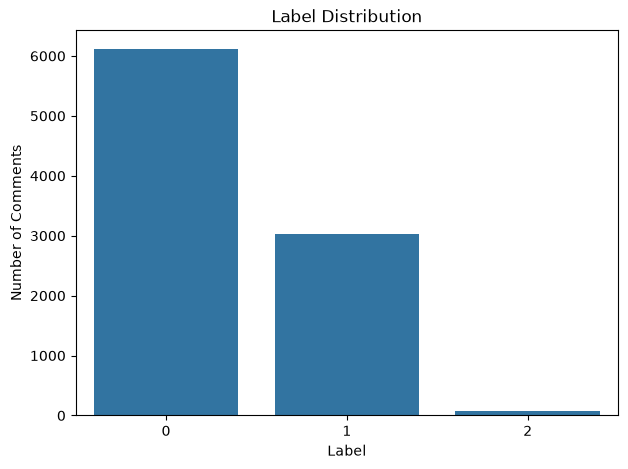

In [7]:
label_counts = df[LABEL_COLUMN].value_counts().sort_index()

print("Label distribution:")
display(label_counts)

label_percentages = (
    df[LABEL_COLUMN]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Label percentages:")
display(label_percentages)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=LABEL_COLUMN,
    order=sorted(df[LABEL_COLUMN].dropna().unique())
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.show()

In [8]:
df_binary = df[df[LABEL_COLUMN].isin([0, 1])].copy()

df_binary = df_binary.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])

df_binary[TEXT_COLUMN] = (
    df_binary[TEXT_COLUMN]
    .astype(str)
    .str.strip()
)

df_binary = df_binary[
    df_binary[TEXT_COLUMN] != ""
].copy()

df_binary[LABEL_COLUMN] = df_binary[LABEL_COLUMN].astype(int)

print("Binary dataset shape:", df_binary.shape)

print("\nBinary label distribution:")
display(df_binary[LABEL_COLUMN].value_counts().sort_index())

Binary dataset shape: (9147, 13)

Binary label distribution:


manual_label
0    6119
1    3028
Name: count, dtype: int64

In [9]:
X = df_binary[TEXT_COLUMN]
y = df_binary[LABEL_COLUMN]

print("Number of text samples:", len(X))
print("Number of labels:", len(y))

Number of text samples: 9147
Number of labels: 9147


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting distribution:")
print(y_test.value_counts().sort_index())

Training rows: 7317
Testing rows: 1830

Training distribution:
manual_label
0    4895
1    2422
Name: count, dtype: int64

Testing distribution:
manual_label
0    1224
1     606
Name: count, dtype: int64


In [11]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (7317, 14862)
Testing TF-IDF shape: (1830, 14862)


In [12]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

logistic_predictions = logistic_model.predict(X_test_tfidf)

In [13]:
print("Logistic Regression results")
print("-" * 40)

print("Accuracy:", round(
    accuracy_score(y_test, logistic_predictions), 4
))

print("Balanced accuracy:", round(
    balanced_accuracy_score(y_test, logistic_predictions), 4
))

print("Precision:", round(
    precision_score(y_test, logistic_predictions, zero_division=0), 4
))

print("Recall:", round(
    recall_score(y_test, logistic_predictions, zero_division=0), 4
))

print("F1-score:", round(
    f1_score(y_test, logistic_predictions, zero_division=0), 4
))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Not security-related",
            "Security-related"
        ],
        zero_division=0
    )
)

Logistic Regression results
----------------------------------------
Accuracy: 0.9705
Balanced accuracy: 0.9563
Precision: 0.9964
Recall: 0.9142
F1-score: 0.9535

Classification report:
                      precision    recall  f1-score   support

Not security-related       0.96      1.00      0.98      1224
    Security-related       1.00      0.91      0.95       606

            accuracy                           0.97      1830
           macro avg       0.98      0.96      0.97      1830
        weighted avg       0.97      0.97      0.97      1830



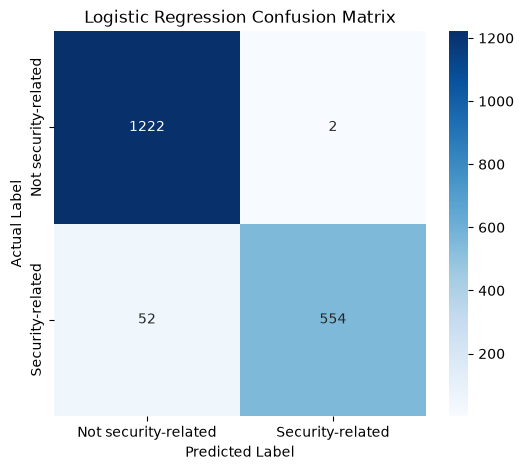

In [14]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not security-related",
        "Security-related"
    ],
    yticklabels=[
        "Not security-related",
        "Security-related"
    ]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [15]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

In [16]:
print("Linear SVM results")
print("-" * 40)

print("Accuracy:", round(
    accuracy_score(y_test, svm_predictions), 4
))

print("Balanced accuracy:", round(
    balanced_accuracy_score(y_test, svm_predictions), 4
))

print("Precision:", round(
    precision_score(y_test, svm_predictions, zero_division=0), 4
))

print("Recall:", round(
    recall_score(y_test, svm_predictions, zero_division=0), 4
))

print("F1-score:", round(
    f1_score(y_test, svm_predictions, zero_division=0), 4
))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=[
            "Not security-related",
            "Security-related"
        ],
        zero_division=0
    )
)

Linear SVM results
----------------------------------------
Accuracy: 0.976
Balanced accuracy: 0.9649
Precision: 0.9947
Recall: 0.9323
F1-score: 0.9625

Classification report:
                      precision    recall  f1-score   support

Not security-related       0.97      1.00      0.98      1224
    Security-related       0.99      0.93      0.96       606

            accuracy                           0.98      1830
           macro avg       0.98      0.96      0.97      1830
        weighted avg       0.98      0.98      0.98      1830



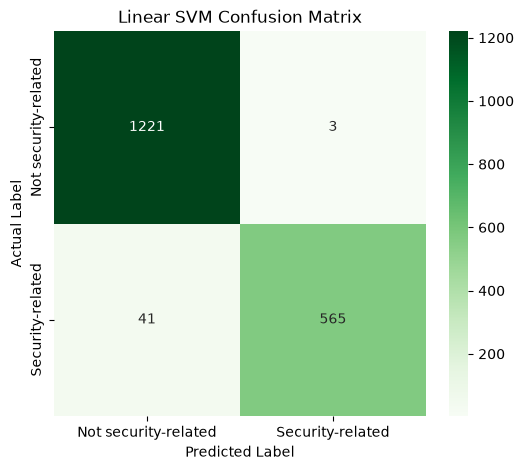

In [17]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "Not security-related",
        "Security-related"
    ],
    yticklabels=[
        "Not security-related",
        "Security-related"
    ]
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [18]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, svm_predictions)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, logistic_predictions),
        balanced_accuracy_score(y_test, svm_predictions)
    ],
    "Precision": [
        precision_score(y_test, logistic_predictions, zero_division=0),
        precision_score(y_test, svm_predictions, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, logistic_predictions, zero_division=0),
        recall_score(y_test, svm_predictions, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, logistic_predictions, zero_division=0),
        f1_score(y_test, svm_predictions, zero_division=0)
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9705,0.9563,0.9964,0.9142,0.9535
1,Linear SVM,0.9760,0.9649,0.9947,0.9323,0.9625
